# 01 - Data Exploration: Suzuki Coupling Dataset

### 🔬 Chemical Context & Motivation

The **Suzuki-Miyaura** coupling is one of the most important and widely used reactions in modern organic chemistry. It is a reaction between a boronic acid (or ester) and an organic halide or triflate, in the presence of a base. The mechanism is a palladium-catalyzed cross-coupling. The general reaction is described below :


$$\text{Ar-X} + \text{Ar'-B(OH)}_2 \xrightarrow[\text{base, solvant}]{\text{Pd(0)}} \text{Ar-Ar'} + \text{X-B(OH)}_2$$


This reaction is now essential for the **synthesis of many important drugs**, such as Valsartan, Losartan, and antiviral compounds. It is also widely used to build biaryl bonds, which are ubiquitous in biologically active molecules.

The yield of this reaction is highly dependent on the interactions between the substrates, the ligand, the base, and the solvent. Identifying optimal conditions currently relies on a time- and resource-intensive trial-and-error approach. The objective of this project is therefore to develop a machine learning model capable of **predicting the reaction yield** for any given combination of reactants in order to recommend the optimal catalytic system (ligand + base + solvent).


### 📊 Dataset Origin

The dataset explored in this notebook (`aap9112_data_file_s1.xlsx`) originates from the seminal work by **Perera et al. (*Science*, 2018)**: *"A platform for automated nanomole-scale reaction screening and micromole-scale synthesis in flow"*.


### 🎯 Goals of this exploration

Before engineering features (like molecular descriptors or fingerprints) for our ML model, we must understand the purely statistical and experimental structure of the raw data. 


**Key questions:**
1. How many reactions are recorded?
2. What columns / features are available?
3. What does the target variable (yield) look like?
4. Which catalysts appear, and how are they distributed?
5. How much missing data is there?

In [2]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Load the raw dataset
DATA_PATH = os.path.join("..", "data", "raw", "aap9112_data_file_s1.xlsx")
df = pd.read_excel(DATA_PATH)

## 1. First Look at the Data

Initially, we begin with a visual overview of the dataset to familiarize ourselves with it. This first step allows us to identify the available columns, the types of variables, and the number of entries. It also helps us understand how the reagents, conditions, and yields are represented.

In [3]:
# Display the first few rows of the dataset
df.head()

,Reaction_No,Reactant_1_Name,Reactant_1_Short_Hand,Reactant_1_eq,Reactant_1_mmol,Reactant_2_Name,Reactant_2_eq,Catalyst_1_Short_Hand,Catalyst_1_eq,Ligand_Short_Hand,Ligand_eq,Reagent_1_Short_Hand,Reagent_1_eq,Solvent_1_Short_Hand,Product_Yield_PCT_Area_UV,Product_Yield_Mass_Ion_Count
0,1,6-chloroquinoline,"1a, 6-Cl-Q",1,0.0004,"2a, Boronic Acid",1,Pd(OAc)2,0.0625,P(tBu)3,0.125,NaOH,2.5,MeCN,4.764109,6262.058822
1,2,6-chloroquinoline,"1a, 6-Cl-Q",1,0.0004,"2a, Boronic Acid",1,Pd(OAc)2,0.0625,P(Ph)3,0.125,NaOH,2.5,MeCN,4.120962,13245.570909
2,3,6-chloroquinoline,"1a, 6-Cl-Q",1,0.0004,"2a, Boronic Acid",1,Pd(OAc)2,0.0625,AmPhos,0.125,NaOH,2.5,MeCN,2.583837,3009.165946
3,4,6-chloroquinoline,"1a, 6-Cl-Q",1,0.0004,"2a, Boronic Acid",1,Pd(OAc)2,0.0625,P(Cy)3,0.125,NaOH,2.5,MeCN,4.443171,30860.698262
4,5,6-chloroquinoline,"1a, 6-Cl-Q",1,0.0004,"2a, Boronic Acid",1,Pd(OAc)2,0.0625,P(o-Tol)3,0.125,NaOH,2.5,MeCN,1.949874,2486.306423


In [4]:
# Display column names and data types
df.dtypes

Reaction_No                       int64
Reactant_1_Name                     str
Reactant_1_Short_Hand               str
Reactant_1_eq                     int64
Reactant_1_mmol                 float64
Reactant_2_Name                     str
Reactant_2_eq                     int64
Catalyst_1_Short_Hand               str
Catalyst_1_eq                   float64
Ligand_Short_Hand                   str
Ligand_eq                       float64
Reagent_1_Short_Hand                str
Reagent_1_eq                    float64
Solvent_1_Short_Hand                str
Product_Yield_PCT_Area_UV       float64
Product_Yield_Mass_Ion_Count    float64
dtype: object

In [5]:
# Display basic information about the dataset
print(f"Dataset loaded: {df.shape[0]} rows × {df.shape[1]} columns")

Dataset loaded: 5760 rows × 16 columns


### Meaning of the Columns

Here is a simple definition of the dataset columns:

| Column | Quick definition |
|---|---|
| `Reaction_No` | Unique identifier of the reaction. |
| `Reactant_1_Name` | Full name of the first reactant. |
| `Reactant_1_Short_Hand` | Short name of the first reactant. |
| `Reactant_1_eq` | Amount of the first reactant in equivalents. |
| `Reactant_1_mmol` | Amount of the first reactant in millimoles. |
| `Reactant_2_Name` | Name of the second reactant. |
| `Reactant_2_eq` | Amount of the second reactant in equivalents. |
| `Catalyst_1_Short_Hand` | Short name of the catalyst used. |
| `Catalyst_1_eq` | Amount of catalyst in equivalents. |
| `Ligand_Short_Hand` | Short name of the ligand used with the catalyst. |
| `Ligand_eq` | Amount of ligand in equivalents. |
| `Reagent_1_Short_Hand` | Short name of the auxiliary reagent, here generally the base. |
| `Reagent_1_eq` | Amount of this auxiliary reagent in equivalents. |
| `Solvent_1_Short_Hand` | Short name of the solvent used. |
| `Product_Yield_PCT_Area_UV` | Product yield measured by UV area (%) ; main target variable. |
| `Product_Yield_Mass_Ion_Count` | Product yield estimated from ion-count signal (mass spectrometry). |

## 2. Missing Values Analysis

Here, we analyze the missing values ​​in the dataset. For each column, we calculate the number and percentage of missing values. This step is essential before any preprocessing, as **missing values ​​can skew the model training**.


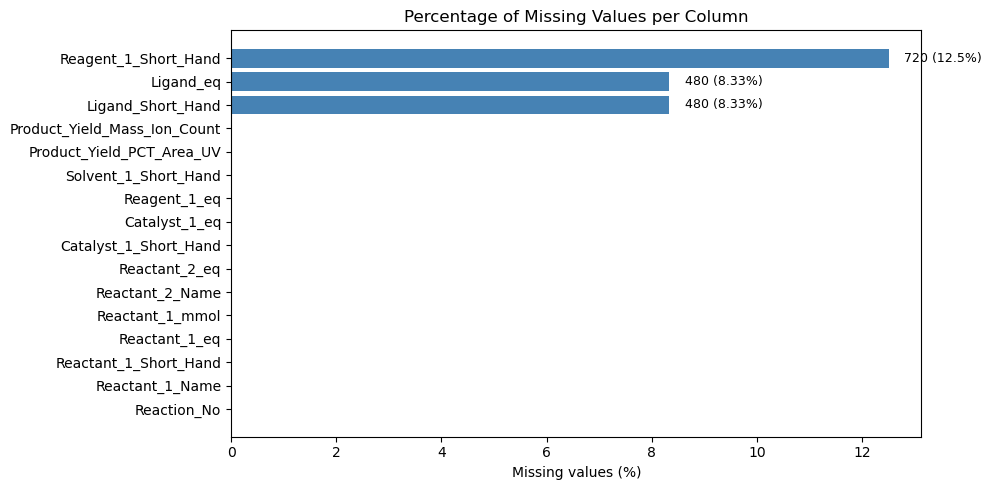

In [6]:
# Count and percentage of missing values per column
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({"Missing": missing, "% Missing": missing_pct})
missing_df = missing_df.sort_values("% Missing", ascending=True)

if (missing_df["Missing"] == 0).all():
    print("No missing values found!")
else:
    # Simple horizontal bar chart
    colors = ["green" if v == 0 else "steelblue" for v in missing_df["% Missing"]]
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.barh(missing_df.index, missing_df["% Missing"], color=colors)
    ax.set_xlabel("Missing values (%)")
    ax.set_title("Percentage of Missing Values per Column")
    # Annotate bars with actual counts
    for i, (pct, cnt) in enumerate(zip(missing_df["% Missing"], missing_df["Missing"])):
        if cnt > 0:
            ax.text(pct + 0.3, i, f"{cnt} ({pct}%)", va="center", fontsize=9)
    plt.tight_layout()
    plt.show()

The graph shows that only three columns have missing values :

- `Reagent_1_Short_Hand` : 720 missing values (**12.5%**)
- `Ligand_eq` : 480 missing values (**8.33%**)
- `Ligand_Short_Hand` : 480 missing values (**8.33%**)

These missing values ​​do not appear to be random. They correspond to experiments carried out without base (`Reagent_1`), or without ligand (`Ligand`). To get to the bottom of this, let's see what these lines with missing values ​​look like.

In [7]:
# Show reactions with at least one missing value
cols_with_missing = df.columns[df.isnull().any()].tolist()
df_missing = df[df[cols_with_missing].isnull().any(axis=1)]

print(f"{len(df_missing)} reactions have at least one missing value\n")

# Display the relevant columns for these reactions
selected_cols = list(dict.fromkeys(
    ["Reaction_No", "Reactant_1_Short_Hand", "Reactant_2_Name", "Reagent_1_eq"] + cols_with_missing
))
display(df_missing[selected_cols].head(20))

1140 reactions have at least one missing value



,Reaction_No,Reactant_1_Short_Hand,Reactant_2_Name,Reagent_1_eq,Ligand_Short_Hand,Ligand_eq,Reagent_1_Short_Hand
11,12,"1a, 6-Cl-Q","2a, Boronic Acid",2.5,NaN,NaN,NaOH
23,24,"1a, 6-Cl-Q","2a, Boronic Acid",2.5,NaN,NaN,NaHCO3
35,36,"1a, 6-Cl-Q","2a, Boronic Acid",2.5,NaN,NaN,CsF
47,48,"1a, 6-Cl-Q","2a, Boronic Acid",2.5,NaN,NaN,K3PO4
59,60,"1a, 6-Cl-Q","2a, Boronic Acid",2.5,NaN,NaN,KOH
71,72,"1a, 6-Cl-Q","2a, Boronic Acid",2.5,NaN,NaN,LiOtBu
83,84,"1a, 6-Cl-Q","2a, Boronic Acid",2.5,NaN,NaN,Et3N
84,85,"1a, 6-Cl-Q","2a, Boronic Acid",2.5,P(tBu)3,0.125,NaN
85,86,"1a, 6-Cl-Q","2a, Boronic Acid",2.5,P(Ph)3,0.125,NaN
86,87,"1a, 6-Cl-Q","2a, Boronic Acid",2.5,AmPhos,0.125,NaN


**Observation - Missing values are intentional controls**

The table above confirms that the missing values are **not random data corruption** but deliberate experimental choices from the HTE plate design:

- **480 reactions without ligand** (`Ligand_Short_Hand` = NaN, `Ligand_eq` = NaN): these are **control experiments** testing whether Pd(OAc)₂ alone, without any phosphine ligand, can catalyze the coupling. This is a standard practice in HTE screening to establish a baseline.
- **720 reactions without base** (`Reagent_1_Short_Hand` = NaN): similarly, these test whether the transmetalation can proceed without base activation. Furthermore, we observe that these reactions still have a basis equivalent (`Reagent_1_eq`) of 2.5. Therefore, care must be taken to address this issue to avoid any problems with the model that could lead to a misinterpretation.

**Decision for data cleaning (Notebook 02):** These rows will **not** be deleted or imputed. Instead, NaN values will be encoded as explicit categories (`"None"` for categorical columns, `0.0` for equivalents), since "no ligand" and "no base" are meaningful experimental conditions that the ML model must learn from. With regard to baseless reactions, care must be taken to establish the base equivalent of `0.0`.

## 3. Target Variable: Yield Distribution

As stated previously, the variable targeted by our ML model is the **reaction yield**. However, this dataset presents two yields measured using different analytical techniques.


- **Product_Yield_PCT_Area_UV** - yield estimated from HPLC UV area %. The reaction products are separated and then passed through a UV detector; the more concentrated a compound is, the more light it absorbs. The yield is then calculated as the ratio between the peak area of ​​the product and the total area. The detector's response is therefore proportional to the concentration.
- **Product_Yield_Mass_Ion_Count** - yield estimated from mass-spec ion count. The molecules are ionized and then counted according to their mass. LC-MS is extremely sensitive and can detect minute traces of a product, but its effectiveness varies depending on the structure of the molecule and the conditions.


The yield determined by HPLC-UV therefore appears to be the most quantitatively reliable. For the remainder of this discussion, we will use `Product_Yield_PCT_Area_UV` as our primary target, but we will still compare the two and attempt to find a correlation between them.

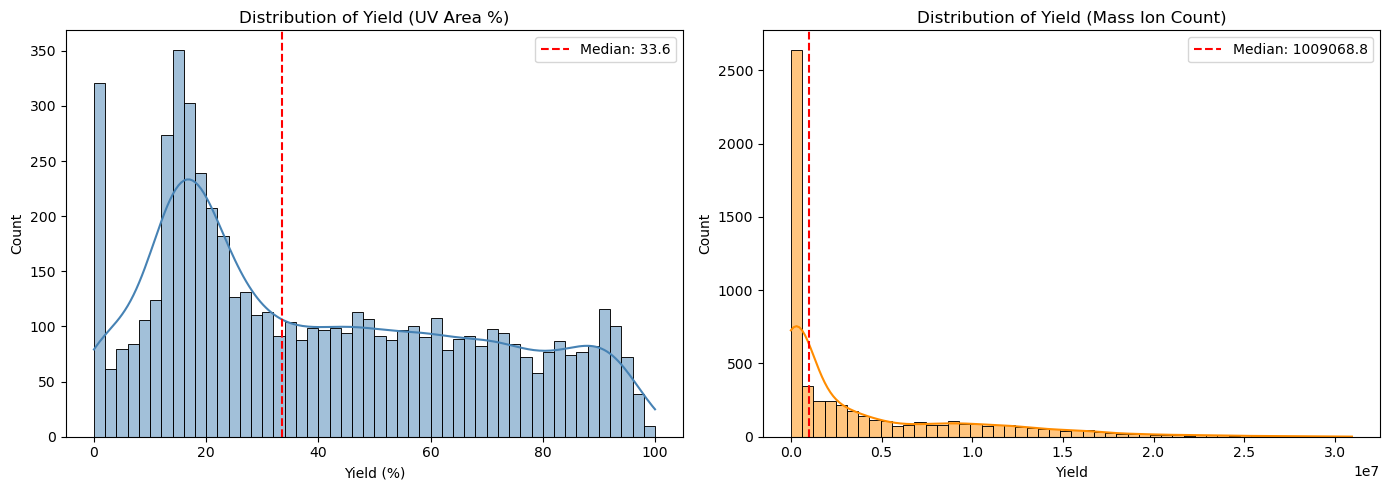

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Yield UV
sns.histplot(df["Product_Yield_PCT_Area_UV"], bins=50, kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Distribution of Yield (UV Area %)")
axes[0].set_xlabel("Yield (%)")
axes[0].axvline(df["Product_Yield_PCT_Area_UV"].median(), color="red", ls="--", label=f'Median: {df["Product_Yield_PCT_Area_UV"].median():.1f}')
axes[0].legend()

# Yield Mass Ion Count
sns.histplot(df["Product_Yield_Mass_Ion_Count"], bins=50, kde=True, ax=axes[1], color="darkorange")
axes[1].set_title("Distribution of Yield (Mass Ion Count)")
axes[1].set_xlabel("Yield")
axes[1].axvline(df["Product_Yield_Mass_Ion_Count"].median(), color="red", ls="--", label=f'Median: {df["Product_Yield_Mass_Ion_Count"].median():.1f}')
axes[1].legend()

plt.tight_layout()
plt.show()

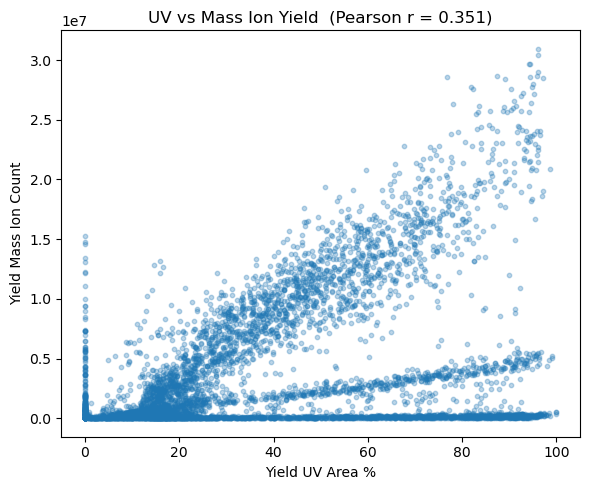

In [9]:
# Correlation between the two yield measures
corr = df["Product_Yield_PCT_Area_UV"].corr(df["Product_Yield_Mass_Ion_Count"])

# Scatter plot of the two yield measures
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(df["Product_Yield_PCT_Area_UV"], df["Product_Yield_Mass_Ion_Count"], alpha=0.3, s=10)
ax.set_xlabel("Yield UV Area %")
ax.set_ylabel("Yield Mass Ion Count")
ax.set_title(f"UV vs Mass Ion Yield  (Pearson r = {corr:.3f})")
plt.tight_layout()
plt.show()

### Comparison of the two yield measurements

**Distribution of reaction yields**

The two distributions are fundamentally different. Regarding the UV yield, it appears **relatively distributed** across the entire 0-100% range, with a peak around 15-20% and a median of **33.6%**, indicating variability in the reaction conditions tested. Conversely, the yield calculated using mass spectrometry is **strongly skewed to the left**, with the vast majority of values ​​concentrated near 0 and a median of approximately **1 × 10⁶**.

**Correlation UV vs MS**

A correlation of **r = 0.351** was calculated between the two analytical techniques. This is a rather weak correlation for two methods intended to measure the same phenomenon. Although a general positive trend is observed, with high UV yields corresponding to high ion counts, the dispersion remains considerable. For example, many reactions exhibit a high UV yield but a near-zero MS count.

**Target variable selection**

This comparison justifies our choice to keep **`Product_Yield_PCT_Area_UV`** as the target variable for our model :

- Expressed as a percentage, directly interpretable
- More even distribution facilitates learning
- Based on a rigorous physical law, Beer-Lambert

## 4. Categorical Features: Reaction Components

During a Suzuki-Miyaura coupling, the yield depends on a set of experimental factors. This dataset was generated on an High-Throughput Experimentation (HTE) platform, where a limited but carefully chosen set of components was systematically varied to explore a wide range of possible reaction conditions.

Let's see how many unique values each has, and their distributions.

In [10]:
cat_cols = [
    "Reactant_1_Short_Hand", "Reactant_2_Name",
    "Catalyst_1_Short_Hand", "Ligand_Short_Hand",
    "Reagent_1_Short_Hand", "Solvent_1_Short_Hand",
]

for col in cat_cols:
    nunique = df[col].nunique()
    print(f"{col:30s}  →  {nunique} unique values: {list(df[col].dropna().unique())}")

Reactant_1_Short_Hand           →  7 unique values: ['1a, 6-Cl-Q', '1b, 6-Br-Q', '1c, 6-OTf-Q', '1d, 6-I-Q', '1e, 6-BOH2-Q', '1g, 6-BF3K-Q', '1f, 6-BPin-Q']
Reactant_2_Name                 →  4 unique values: ['2a, Boronic Acid', '2b, Boronic Ester', '2c, Trifluoroborate', '2d, Bromide']
Catalyst_1_Short_Hand           →  1 unique values: ['Pd(OAc)2']
Ligand_Short_Hand               →  11 unique values: ['P(tBu)3', 'P(Ph)3 ', 'AmPhos', 'P(Cy)3', 'P(o-Tol)3', 'CataCXium A', 'SPhos', 'dtbpf', 'XPhos', 'dppf', 'Xantphos']
Reagent_1_Short_Hand            →  7 unique values: ['NaOH', 'NaHCO3', 'CsF', 'K3PO4', 'KOH', 'LiOtBu', 'Et3N']
Solvent_1_Short_Hand            →  6 unique values: ['MeCN', 'THF', 'DMF', 'MeOH', 'MeOH/H2O_V2 9:1', 'THF_V2']


| Component | Role in the reaction | Count |
|---|---|---|
| **Reactant 1** (Electrophile) | Aryl halide / pseudohalide that couples with the nucleophile | 7 |
| **Reactant 2** (Nucleophile) | Organoboron species (boronic acid, ester, or BF₃K salt) | 4 |
| **Catalyst** | Pd precursor - **constant** across all reactions (Pd(OAc)₂) | 1 |
| **Ligand** | Phosphine that tunes catalyst activity and selectivity | 11 + "none" |
| **Base** | Activates the organoboron partner for transmetalation | 7 + "none" |
| **Solvent** | Reaction medium - affects solubility and catalyst stability | 6 |

Since the catalyst ($\text{Pd(OAc)}_2$) is **constant** across all 5 760 reactions, it will not be used as a feature for model training. The optimization space is therefore defined by the remaining five variables.

It is also important to note the presence of `THF` and `THF_V2`. Both have the same chemical structure but were nevertheless differentiated by the author of the dataset. The difference could stem from different experimental batches, such as a different THF source. These two solvents will be compared later in terms of their impact on their yield.

### 4.1 Yield by Reactants

In order to understand the influence of each parameter on the yield, we decided to represent the distribution of the yield by **reactants** using boxplots. Each box gives the median, interquartile range, and outliers for each of the reactants.

However, this analysis remains approximate since it **completely disregards the interactions between variables**. For example, a reactant might only perform well when combined with a specific base. These potential interactions will be examined in Part 5, using heatmaps.

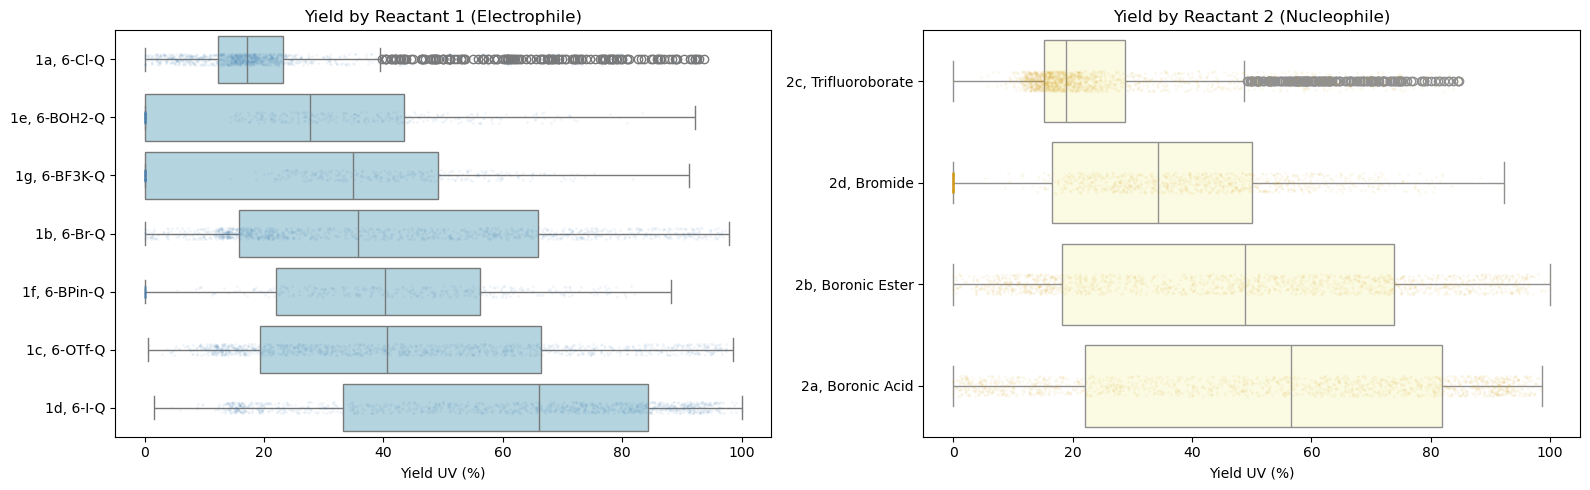

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Reactant 1
order_r1 = df.groupby("Reactant_1_Short_Hand")["Product_Yield_PCT_Area_UV"].median().sort_values().index
sns.boxplot(data=df, y="Reactant_1_Short_Hand", x="Product_Yield_PCT_Area_UV",
            order=order_r1, color="lightblue", ax=axes[0])
sns.stripplot(data=df, y="Reactant_1_Short_Hand", x="Product_Yield_PCT_Area_UV",
              order=order_r1, color="steelblue", alpha=0.08, size=2, ax=axes[0])
axes[0].set_title("Yield by Reactant 1 (Electrophile)")
axes[0].set_xlabel("Yield UV (%)")
axes[0].set_ylabel("")

# Reactant 2
order_r2 = df.groupby("Reactant_2_Name")["Product_Yield_PCT_Area_UV"].median().sort_values().index
sns.boxplot(data=df, y="Reactant_2_Name", x="Product_Yield_PCT_Area_UV",
            order=order_r2, color="lightyellow", ax=axes[1])
sns.stripplot(data=df, y="Reactant_2_Name", x="Product_Yield_PCT_Area_UV",
              order=order_r2, color="goldenrod", alpha=0.08, size=2, ax=axes[1])
axes[1].set_title("Yield by Reactant 2 (Nucleophile)")
axes[1].set_xlabel("Yield UV (%)")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

**Observations - Reactants**

The electrophile is the most determining factor: iodide (1d) gives the best yields, followed by triflate (1c). Boron substrates (1e, 1f, 1g) are significantly less efficient. The differences between nucleophiles are smaller but still noticeable.

### 4.2 Yield by Ligand & Base

The **ligand** and the **base** are probably the two most influential factors, given that the catalyst ($\text{Pd(OAc)}_2$) is fixed. Indeed, the ligand controls the steric and electronic environment around the Pd center. The base, for its part, activates the organoboron partner for transmetalation.

Just as with the reagents, we will study the distribution of yields according to each of the ligands and bases.

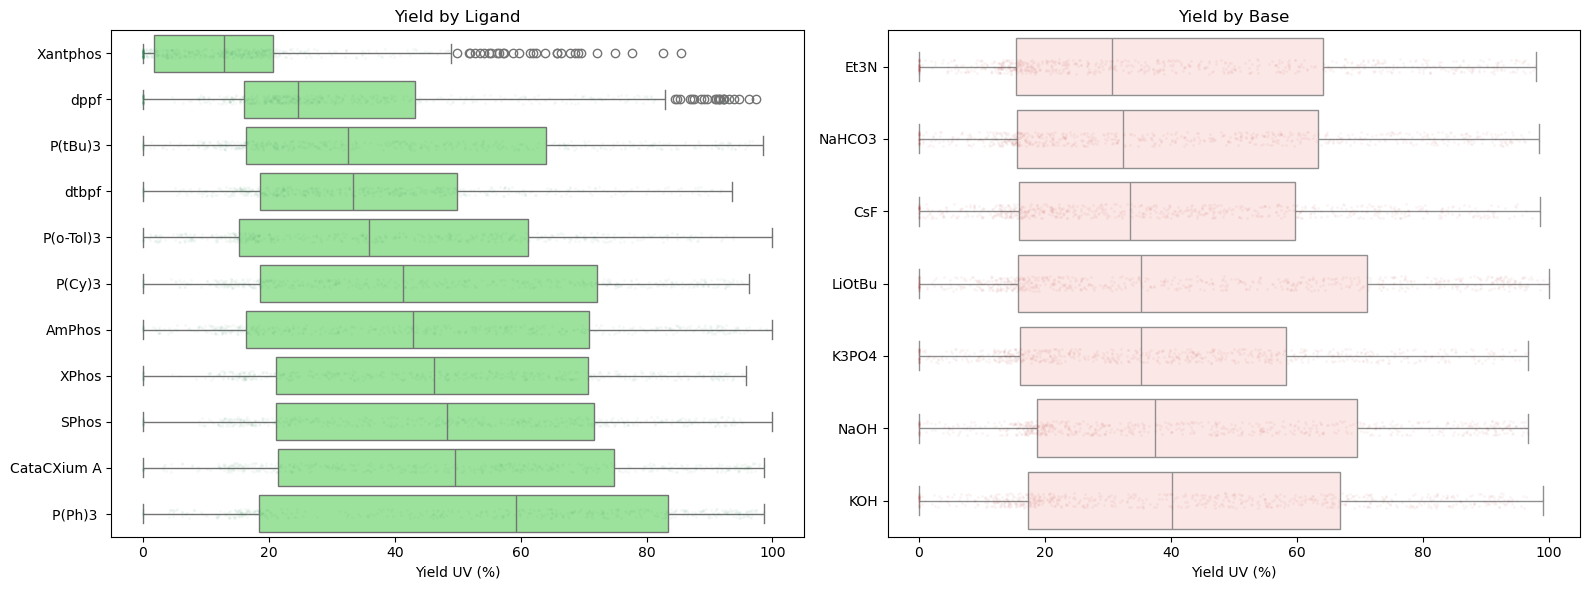

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Ligand
order_lig = (df.dropna(subset=["Ligand_Short_Hand"])
             .groupby("Ligand_Short_Hand")["Product_Yield_PCT_Area_UV"]
             .median().sort_values().index)
sns.boxplot(data=df.dropna(subset=["Ligand_Short_Hand"]),
            y="Ligand_Short_Hand", x="Product_Yield_PCT_Area_UV",
            order=order_lig, color="lightgreen", ax=axes[0])
sns.stripplot(data=df.dropna(subset=["Ligand_Short_Hand"]),
              y="Ligand_Short_Hand", x="Product_Yield_PCT_Area_UV",
              order=order_lig, color="seagreen", alpha=0.05, size=2, ax=axes[0])
axes[0].set_title("Yield by Ligand")
axes[0].set_xlabel("Yield UV (%)")
axes[0].set_ylabel("")

# Base
order_base = (df.dropna(subset=["Reagent_1_Short_Hand"])
              .groupby("Reagent_1_Short_Hand")["Product_Yield_PCT_Area_UV"]
              .median().sort_values().index)
sns.boxplot(data=df.dropna(subset=["Reagent_1_Short_Hand"]),
            y="Reagent_1_Short_Hand", x="Product_Yield_PCT_Area_UV",
            order=order_base, color="mistyrose", ax=axes[1])
sns.stripplot(data=df.dropna(subset=["Reagent_1_Short_Hand"]),
              y="Reagent_1_Short_Hand", x="Product_Yield_PCT_Area_UV",
              order=order_base, color="firebrick", alpha=0.05, size=2, ax=axes[1])
axes[1].set_title("Yield by Base")
axes[1].set_xlabel("Yield UV (%)")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

**Observations - Ligand**

The dispersion of yields among ligands is significant. However, **P(Ph)₃** emerges as the most efficient. Furthermore, some ligands exhibit a very wide distribution, suggesting they are extremely sensitive to other conditions. This will be explored further in Part 5 using heatmaps.

**Observations - Base**

**KOH** and **K₃PO₄** are the most efficient bases. All bases have a highly distributed interquartile range, suggesting that all bases are extremely dependent on other factors.

### 4.3 Yield by Solvent

The solvent must play a dual role; dissolving the reactants and maintaining the stability of the catalyst.

We decided to use a **violin plot** because it allows us to better compare the range of yields each solvent can achieve. In short, it allows us to see if a solvent produces **bimodal yields** (two yield values), or conversely, is highly concentrated around a **single value**, which a classic boxplot would obscure.


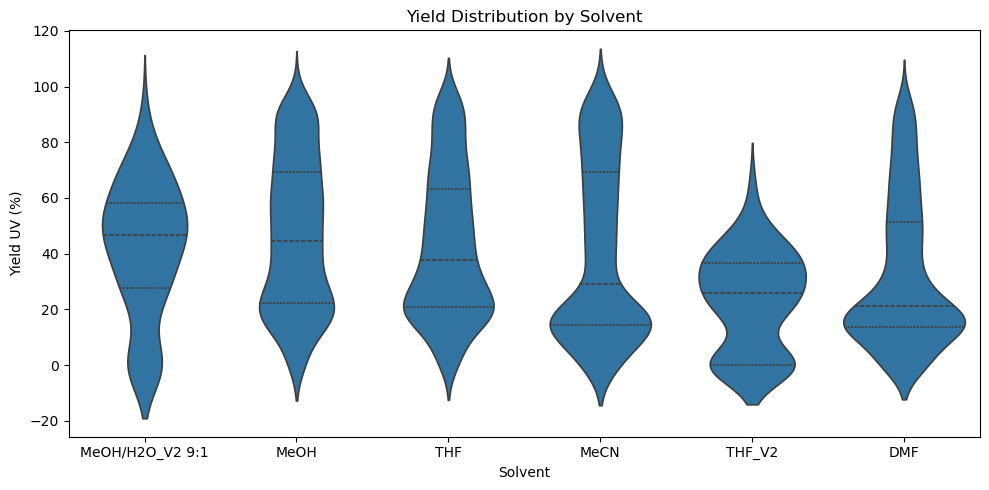

In [13]:
fig, ax = plt.subplots(figsize=(10, 5))
order_sol = df.groupby("Solvent_1_Short_Hand")["Product_Yield_PCT_Area_UV"].median().sort_values(ascending=False).index
sns.violinplot(data=df, x="Solvent_1_Short_Hand", y="Product_Yield_PCT_Area_UV", order=order_sol, inner="quartile", ax=ax)
ax.set_title("Yield Distribution by Solvent")
ax.set_ylabel("Yield UV (%)")
ax.set_xlabel("Solvent")
plt.tight_layout()
plt.show()

**Observations - Solvent**

The **MeOH/H₂O (9:1)** mixture exhibits the highest median value. Aqueous protic solvents promote Suzuki coupling by solubilizing the inorganic base and stabilizing the boronate intermediate. Whereas purely organic solvents (THF) have wider distributions and lower medians.

Thus, the **polarity** and **aprotic/protic** character of the solvent could be good numerical descriptors during **feature engineering**.

**Note :** As mentioned earlier, the two versions of THF have an identical structure, yet this graph shows us that the yields are different. To get a better idea of ​​the difference, let's look at the yield distribution of each.

In [14]:
# Compare THF vs THF_V2 yield distributions
thf_stats = (
    df[df["Solvent_1_Short_Hand"].isin(["THF", "THF_V2"])]
    .groupby("Solvent_1_Short_Hand")["Product_Yield_PCT_Area_UV"]
    .agg(Median="median", Std="std", Count="count")
    .round(2)
)
display(thf_stats)

,Median,Std,Count
Solvent_1_Short_Hand,,,
THF,37.59,26.35,1344
THF_V2,25.73,17.57,96


We see a 12% difference in the median yield of the two solvents. Keeping both solvents in the dataset could distort our model, which recognizes that for the same chemical structure and conditions, the same yield is not necessarily observed. The same would be true if we tried to merge them. The solution to avoid any bias in our model would therefore be to completely remove the rows using `THF_V2`, knowing that there are only 96 of them compared to 1344. This is an acceptable loss of information to avoid any problems with our model later on.

## 5. Interaction Heatmap

In part 4, we analyzed each reaction component **independently**. However, in chemistry, the yield is rarely determined by a single factor. It is the **combination** of conditions that matters. A ligand that performs poorly on average might be excellent when paired with a specific base, and vice versa.

To capture these **pairwise interactions**, we use heatmaps where each cell represents the **median yield** across all reactions sharing a given (row, column) combination. This is equivalent to a two-way ANOVA view of the data, and it is the standard visualization in High-Throughput Experimentation (HTE) analysis.

We examine two key interaction maps:
1. **Ligand × Base** - the two main "tunable knobs" for optimizing the catalytic system.
2. **Reactant 1 × Reactant 2** - to check whether certain substrate pairings are intrinsically easier or harder to couple.

### 5.1 Heatmap - Ligand x Base

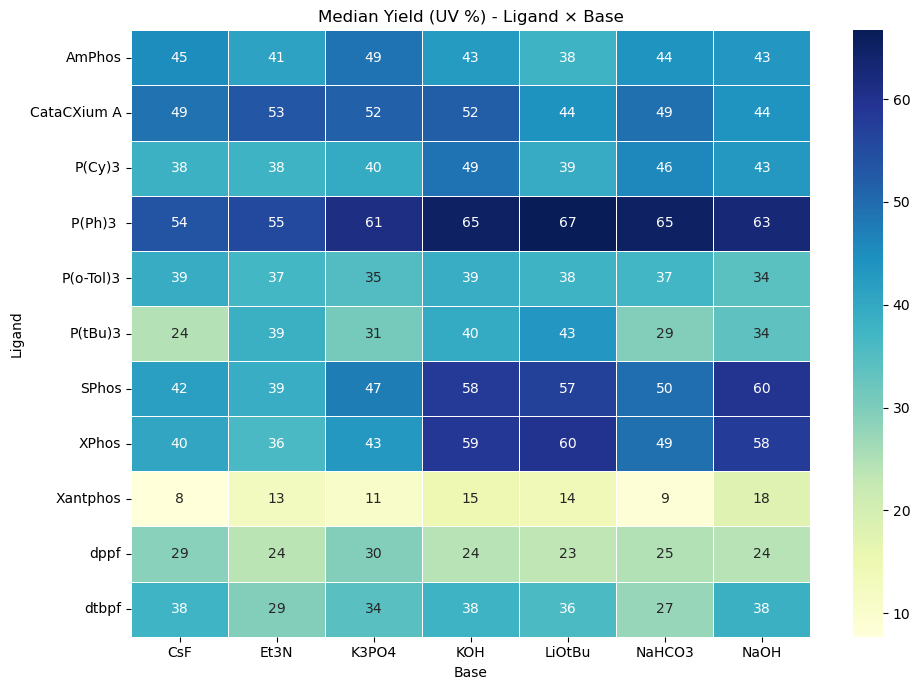

In [15]:
# Pivot: Ligand × Base → median yield
sub = df.dropna(subset=["Ligand_Short_Hand", "Reagent_1_Short_Hand"])
pivot = sub.pivot_table(
    index="Ligand_Short_Hand",
    columns="Reagent_1_Short_Hand",
    values="Product_Yield_PCT_Area_UV",
    aggfunc="median",
)

# Heatmap of median yields for Ligand × Base combinations
fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(pivot, annot=True, fmt=".0f", cmap="YlGnBu", linewidths=0.5, ax=ax)
ax.set_title("Median Yield (UV %) - Ligand × Base")
ax.set_ylabel("Ligand")
ax.set_xlabel("Base")
plt.tight_layout()
plt.show()

**Observations - Ligand × Base interaction**

This heatmap shows that the interactions between certain components are far more significant than the individual effects on the catalytic system. Some Ligand/Base combinations are much more effective than others. The following observations are noted:

- **P(Ph)₃ + KOH** is the best combination
- Some combinations have a yield very low, suggesting an **incompatibility**

### 5.2 Heatmap - Reactant 1 x Reactant 2

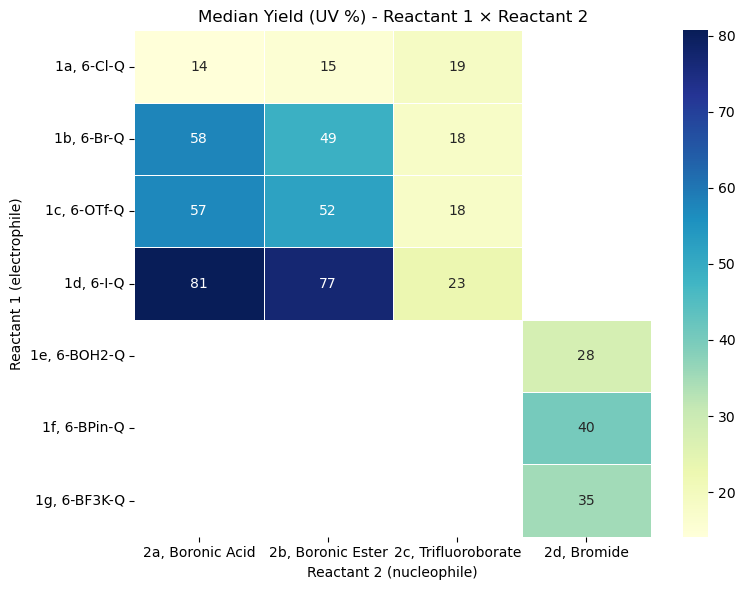

In [16]:
# Pivot: Reactant 1 × Reactant 2 → median yield
pivot2 = df.pivot_table(
    index="Reactant_1_Short_Hand",
    columns="Reactant_2_Name",
    values="Product_Yield_PCT_Area_UV",
    aggfunc="median",
)

# Heatmap of median yields for Reactant 1 × Reactant 2 combinations
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(pivot2, annot=True, fmt=".0f", cmap="YlGnBu", linewidths=0.5, ax=ax)
ax.set_title("Median Yield (UV %) - Reactant 1 × Reactant 2")
ax.set_ylabel("Reactant 1 (electrophile)")
ax.set_xlabel("Reactant 2 (nucleophile)")
plt.tight_layout()
plt.show()

**Observations - Reactant 1 × Reactant 2 interaction**

This heatmap confirms the strong effect of the **leaving group** on Reactant 1 (already observed in Section 4): the iodide row (1d) dominates across all nucleophilic partners. The substrate pairing effect is therefore primarily driven by the electrophile rather than symmetric interactions between the two partners.

However, subtle differences exist across columns: some nucleophiles pair better with specific electrophiles, suggesting that **electronic matching** between the two coupling partners also plays a role, likely through compatibility during the transmetalation step.

From a **modeling perspective**, this heatmap justifies encoding the two reactants as **separate features** rather than combining them into a single "substrate pair" variable. The model needs to independently learn the leaving-group effect (Reactant 1) and the boron-species effect (Reactant 2), while also capturing their interaction through cross-terms or non-linear layers.

## 6. Key Takeaways

| Aspect | Observation | Implication for ML |
|---|---|---|
| **Dataset size** | 5 760 reactions, 16 columns | Sufficient for tree-based or shallow neural network models |
| **Catalyst** | Only Pd(OAc)₂ - constant | Will be dropped as a feature; the model optimizes the **catalytic system** (Ligand + Base + Solvent), not the metal itself |
| **Reactant 1** | 7 electrophiles. Iodide (1d) >> Chloride (1a) | Leaving group identity is a strong predictor - encode as separate feature |
| **Reactant 2** | 4 nucleophiles. Modest differences | Boron species type has a secondary but real effect |
| **Ligands** | 11 ligands + "no ligand". P(Ph)₃ best overall | Wide variance per ligand → strong interactions with other variables |
| **Bases** | 7 bases + "no base". KOH and K₃PO₄ best | No single base is universally optimal - context-dependent |
| **Solvents** | 6 solvents. MeOH/H₂O (9:1) best | Protic/aqueous character matters - polarity could be a useful numerical descriptor |
| **Missing values** | Ligand (8.3%) and Base (12.5%) - intentional controls | Encode as `"None"` category, do not drop or impute |
| **Yield (UV)** | Right-skewed, median ~34%, range 0–100% | Primary target variable. Many failed reactions (yield ≈ 0) - model must handle this |
| **Yield (MS)** | Weakly correlated with UV (r ≈ 0.35) | Will be dropped - unreliable for quantitative regression |
| **Interactions** | Ligand × Base heatmap shows strong pairwise effects | A non-linear model (Random Forest, XGBoost, or NN) is needed to capture these interactions |

### Next Steps (Notebook 02 - Data Cleaning)
1. Encode missing Ligand / Base as `"None"` and set their equivalents to `0.0`
2. Drop constant or redundant columns (`Catalyst_1_Short_Hand`, `Catalyst_1_eq`, `Product_Yield_Mass_Ion_Count`)
3. Standardize column names for consistency
4. Check for and flag potential outliers in the UV yield
5. Save the cleaned dataset to `data/processed/`